## Training Random Forest + Ekspor TFLite — URL Classifier
**Google Colab | Multi-Dataset | Export ke Android**

---
Notebook ini melatih model Random Forest dan mengekspornya ke format TFLite
yang kompatibel dengan aplikasi Android, untuk setiap ukuran dataset secara berurutan.

**Alur kerja:**
1. Load CSV per ukuran dataset dari `DATASET_FILES`
2. Sampling balanced + validasi konsistensi fitur (F5, F7)
3. Training Random Forest dengan hyperparameter terbaik dari tuning
4. Evaluasi (accuracy, F1, AUC-ROC, confusion matrix)
5. Ekspor ke TFLite via pipeline: **sklearn → ONNX → TFLite**
6. Verifikasi TFLite pada seluruh test set
7. Simpan semua output ke subfolder Drive per ukuran dataset

**Catatan konversi:**
- `zipmap=False` saat konversi ONNX → **menghindari error GATHER di Android**
- Fungsi ekstraksi fitur **identik** dengan kode Android (`RandomForestClassifier.kt`)

## Cell 1 — Install Library

Instalasi `skl2onnx` dan `onnx2tf` untuk pipeline konversi ke TFLite.

In [ ]:
# Library standar ML
# CATATAN: jangan upgrade scikit-learn ke 1.9 — skl2onnx belum mendukungnya
# (menyebabkan model ONNX salah total, delta=1.0 vs sklearn)
!pip install -q "scikit-learn<1.9" seaborn

# Pipeline konversi: sklearn -> ONNX (untuk evaluasi & Android)
!pip install -q skl2onnx onnx onnxruntime

# onnx2tf TIDAK dipakai lagi: tidak mendukung op TreeEnsembleClassifier.
# Konversi RF -> TFLite dilakukan langsung dari struktur pohon sklearn (Cell 6).

# Kembalikan paket inti ke versi yang dibutuhkan Colab/TF 2.20
!pip install -q --force-reinstall "numpy>=2.0,<2.6" "pandas==2.2.2" "protobuf>=5.28,<7"

print('Semua library berhasil diinstall.')
print('Runtime akan otomatis restart...')

# Restart runtime otomatis. Setelah restart, lanjut dari Cell 2.
import os
os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 32.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.
grpcio-status 1.

## Cell 2 — Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time
import os
import re
import shutil
import subprocess
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_curve, auc
)

import tensorflow as tf
import onnx
import onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

print(f'scikit-learn : {__import__("sklearn").__version__}')
print(f'TensorFlow   : {tf.__version__}')
print(f'ONNX         : {onnx.__version__}')

scikit-learn : 1.6.1
TensorFlow   : 2.20.0
ONNX         : 1.21.0


## Cell 3 — Mount Google Drive & Konfigurasi

**Format dataset** — CSV dengan kolom minimal:
```
label, domain_length, digit_count, dot_count, delimiter_count,
suspicious_word_count, digit_letter_ratio, max_sequential_digits
```

> `label`: 0 = URL aman, 1 = URL pornografi

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ================================================================
# SESUAIKAN PATH INI
# ================================================================
DATASET_BASE     = '/content/drive/MyDrive/Tugas Akhir/Dataset/'
SAVE_PATH        = '/content/drive/MyDrive/Tugas Akhir/Training/Random-Forest/training_baru/'
BEST_PARAMS_JSON = '/content/drive/MyDrive/Tugas Akhir/Tuning/Random Forest/Random Forestbest_params.json'
LABEL_COL        = 'label'

FEATURE_COLS = [
    'domain_length',
    'digit_count',
    'dot_count',
    'delimiter_count',
    'suspicious_word_count',   # F5: COUNT, bukan boolean
    'digit_letter_ratio',
    'max_sequential_digits'    # F7: panjang MAX, bukan boolean
]

# Daftar file CSV - setiap file = satu ukuran dataset terpisah
# SIZE_LABEL otomatis dari nama file (tanpa ekstensi)
DATASET_FILES = [
    DATASET_BASE + 'extracted_features_100k.csv',
    DATASET_BASE + 'extracted_features_200k.csv',
    DATASET_BASE + 'extracted_features_300k.csv',
]
# ================================================================

os.makedirs(SAVE_PATH, exist_ok=True)
print('Dataset files:')
for fpath in DATASET_FILES:
    size_label = os.path.splitext(os.path.basename(fpath))[0]
    ok = os.path.exists(fpath)
    if ok:
        tmp = pd.read_csv(fpath, usecols=[LABEL_COL])
        n0 = int((tmp[LABEL_COL] == 0).sum())
        n1 = int((tmp[LABEL_COL] == 1).sum())
        print(f'  {size_label}: OK  {len(tmp):,} baris | aman={n0:,} | porno={n1:,}')
    else:
        print(f'  {size_label}: FILE TIDAK ADA - upload dulu ke Drive')

Mounted at /content/drive
Dataset files:
  extracted_features_100k: OK  100,000 baris | aman=50,000 | porno=50,000
  extracted_features_200k: OK  200,000 baris | aman=100,000 | porno=100,000
  extracted_features_300k: OK  300,000 baris | aman=150,000 | porno=150,000


## Cell 4 — Fungsi Ekstraksi Fitur

> **PENTING**: Fungsi ini HARUS IDENTIK dengan `extractLexicalFeatures()` di `RandomForestClassifier.kt`.
> Jika ada perbedaan sekecil apapun, model akan salah mengklasifikasi di Android.

Digunakan untuk:
1. Verifikasi bahwa fitur di dataset konsisten dengan cara hitung Android
2. Mengekstrak fitur dari URL baru jika dataset hanya berisi URL+label

**Perbedaan dengan training sebelumnya:**
- F5 `suspicious_word_count`: sekarang **COUNT** (bisa 0,1,2,...), bukan boolean
- F7 `max_sequential_digits`: sekarang **panjang maksimal** digit berurutan, bukan boolean

In [3]:
# Daftar kata mencurigakan — HARUS SAMA dengan SUSPICIOUS_WORDS di Android
SUSPICIOUS_WORDS = {
    'porn', 'sex', 'xxx', 'adult', 'cam', 'tube', 'bokep', 'hentai',
    'nude', 'gay', 'lesbian', 'erotic', 'mature', 'amateur',
    'creampie', 'milf', 'bbw', 'naked', 'porno', 'anal',
    'pussy', 'cock', 'cumshot', 'orgasm', 'xvideos', 'xnxx',
    'xhamster', 'redtube', 'youporn', 'brazzers', 'onlyfans'
}

def extract_features(domain: str) -> list:
    """
    Ekstrak 7 fitur leksikal dari domain URL.
    Input : 'youporn.com' (domain setelah normalisasi, dengan TLD)
    Output: [F1, F2, F3, F4, F5, F6, F7]
    """
    lower = domain.lower()

    digits  = sum(c.isdigit() for c in lower)           # F2
    letters = sum(c.isalpha() for c in lower)           # untuk F6

    # F5: COUNT kata mencurigakan (identik dgn SUSPICIOUS_WORDS.count{} di Android)
    suspicious_word_count = sum(1 for w in SUSPICIOUS_WORDS if w in lower)

    # F6: digit / letter ratio
    digit_letter_ratio = digits / letters if letters > 0 else float(digits)

    # F7: panjang maksimal urutan digit (identik dgn Regex("\\d+").findAll().maxOfOrNull di Android)
    sequences = re.findall(r'\d+', lower)
    max_sequential_digits = max((len(s) for s in sequences), default=0)

    return [
        len(domain),                                                    # F1: domain_length
        digits,                                                         # F2: digit_count
        lower.count('.'),                                               # F3: dot_count
        sum(1 for c in lower if not c.isalnum() and c != '.'),         # F4: delimiter_count
        suspicious_word_count,                                          # F5: suspicious_word_count
        digit_letter_ratio,                                             # F6: digit_letter_ratio
        max_sequential_digits,                                          # F7: max_sequential_digits
    ]

# Verifikasi dengan contoh konkret — cocokkan dengan logcat Android
test_cases = [
    ('youporn.com',       1, 'F5=1(porn), F7=0'),
    ('xvideos.com',       1, 'F5=1(xvideos), F7=0'),
    ('xxx18hub.com',      1, 'F5=1(xxx), F7=2(dari 18)'),
    ('bba021.com',        0, 'F5=0, F7=3(dari 021)'),
    ('google.com',        0, 'semua fitur rendah'),
    ('hand-job-porn.com', 1, 'F5=1(porn), F4=1(dash), F7=0'),
]

print(f'{"Domain":<25} {"Lbl":<5} {"F1":>4} {"F2":>4} {"F3":>4} {"F4":>4} {"F5":>4} {"F6":>7} {"F7":>4}   Catatan')
print('-' * 95)
for domain, label, note in test_cases:
    f = extract_features(domain)
    print(f'{domain:<25} {label:<5} {f[0]:>4} {f[1]:>4} {f[2]:>4} {f[3]:>4} {f[4]:>4} {f[5]:>7.3f} {f[6]:>4}   {note}')

Domain                    Lbl     F1   F2   F3   F4   F5      F6   F7   Catatan
-----------------------------------------------------------------------------------------------
youporn.com               1       11    0    1    0    2   0.000    0   F5=1(porn), F7=0
xvideos.com               1       11    0    1    0    1   0.000    0   F5=1(xvideos), F7=0
xxx18hub.com              1       12    2    1    0    1   0.222    2   F5=1(xxx), F7=2(dari 18)
bba021.com                0       10    3    1    0    0   0.500    3   F5=0, F7=3(dari 021)
google.com                0       10    0    1    0    0   0.000    0   semua fitur rendah
hand-job-porn.com         1       17    0    1    2    1   0.000    0   F5=1(porn), F4=1(dash), F7=0


## Cell 5 — Load Hyperparameter Terbaik

Notebook akan mencoba membaca `best_params.json` dari hasil tuning.
Jika tidak ada, gunakan nilai default.

In [4]:
DEFAULT_PARAMS = {
    'n_estimators': 200,
    'max_depth'   : 10,
    'max_features': 'sqrt',
}

if os.path.exists(BEST_PARAMS_JSON):
    with open(BEST_PARAMS_JSON) as f:
        best_params = json.load(f)
    print(f'Loaded dari: {BEST_PARAMS_JSON}')
else:
    best_params = DEFAULT_PARAMS
    print('best_params.json tidak ditemukan.')
    print('   Menggunakan default hyperparameter.')
    print('   Jalankan rf_hyperparameter_tuning_v2.ipynb untuk tuning.')

print('Hyperparameter yang akan digunakan:')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')

Loaded dari: /content/drive/MyDrive/Tugas Akhir/Tuning/Random Forest/Random Forestbest_params.json
Hyperparameter yang akan digunakan:
  max_depth             : 10
  max_features          : sqrt
  n_estimators          : 100


## Cell 6 — Training Loop (Multi-Dataset)

Loop ini memproses setiap file CSV di `DATASET_FILES` secara berurutan:
1. Load & balanced sampling per kelas
2. Validasi konsistensi fitur F5 & F7
3. Split 80/20 → training Random Forest
4. Evaluasi (accuracy, F1, AUC-ROC, confusion matrix + distribusi skor)
5. Feature importance plot
6. Cek overfitting (train vs test accuracy)
7. Konversi ke TFLite (sklearn → ONNX → TFLite) + verifikasi pada test set
8. Simpan semua output ke subfolder Drive per ukuran dataset

Estimasi waktu per dataset (CPU Colab): **1–5 menit**

## Cell 5b — Script Konverter TFLite (subprocess)

Jalankan sekali. Menulis `/content/convert_tflite.py` yang dipakai Cell 6 agar konversi TFLite tidak meng-crash kernel.


  extracted_features_100k  (100,000 baris | unik: 4,729 | aman: 50,000 porno: 50,000)
F5 (int count): OK
F7 (max len)  : OK
Train: 71,928 | Test: 28,072 | overlap grup: 0 (OK)
Balance train: 0.541 | test: 0.394

Training extracted_features_100k...
Selesai: 3.0 detik | 100 pohon | max_depth=10

Test Set — extracted_features_100k (prevalence-weighted, seluruh data):
  Accuracy : 0.9860  Precision: 0.9958
  Recall   : 0.9684  F1-Score : 0.9819  AUC: 0.9933
                precision    recall  f1-score   support

      Aman (0)     0.9798    0.9974    0.9885     17013
Pornografi (1)     0.9958    0.9684    0.9819     11059

      accuracy                         0.9860     28072
     macro avg     0.9878    0.9829    0.9852     28072
  weighted avg     0.9861    0.9860    0.9859     28072

  (Referensi) Accuracy pada 910 vektor unik di test: 0.9725


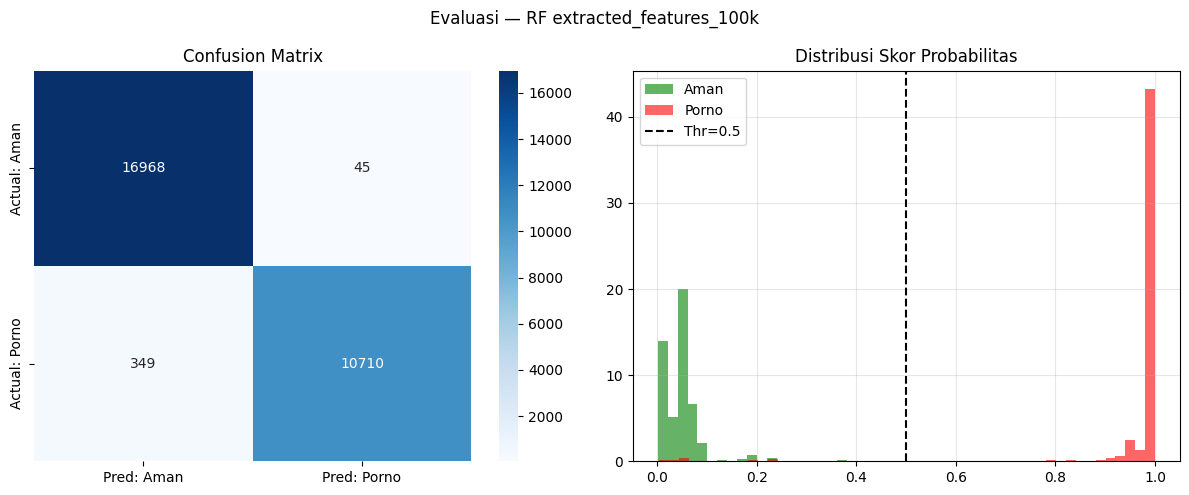

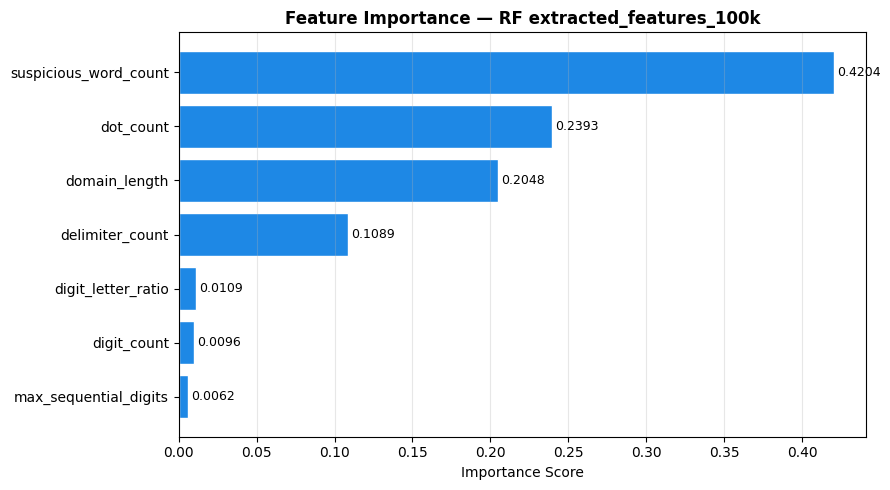

Overfitting: train=0.9821 | test=0.9860 | gap=-0.0038  OK
ONNX out: [0.0716 0.9284] | sklearn: [0.0716 0.9284] | delta: 0.000000 OK
TFLite: 1566.4 KB | 100 pohon | depth=10
TFLite acc=0.9860 | delta=0.0000 OK
  OK url_classifier_rf_extracted_features_100k.tflite
  OK rf_extracted_features_100k.onnx
  OK rf_model_extracted_features_100k.joblib
  OK evaluation_extracted_features_100k.png
  OK feature_importance_extracted_features_100k.png
  OK classification_report_extracted_features_100k.txt

SELESAI extracted_features_100k — acc=0.9860 | f1=0.9819 | auc=0.9933 | 1566.4KB
-----------------------------------------------------------------

  extracted_features_200k  (200,000 baris | unik: 6,476 | aman: 100,000 porno: 100,000)
F5 (int count): OK
F7 (max len)  : OK
Train: 152,654 | Test: 47,346 | overlap grup: 0 (OK)
Balance train: 0.525 | test: 0.420

Training extracted_features_200k...
Selesai: 4.1 detik | 100 pohon | max_depth=10

Test Set — extracted_features_200k (prevalence-weighted, 

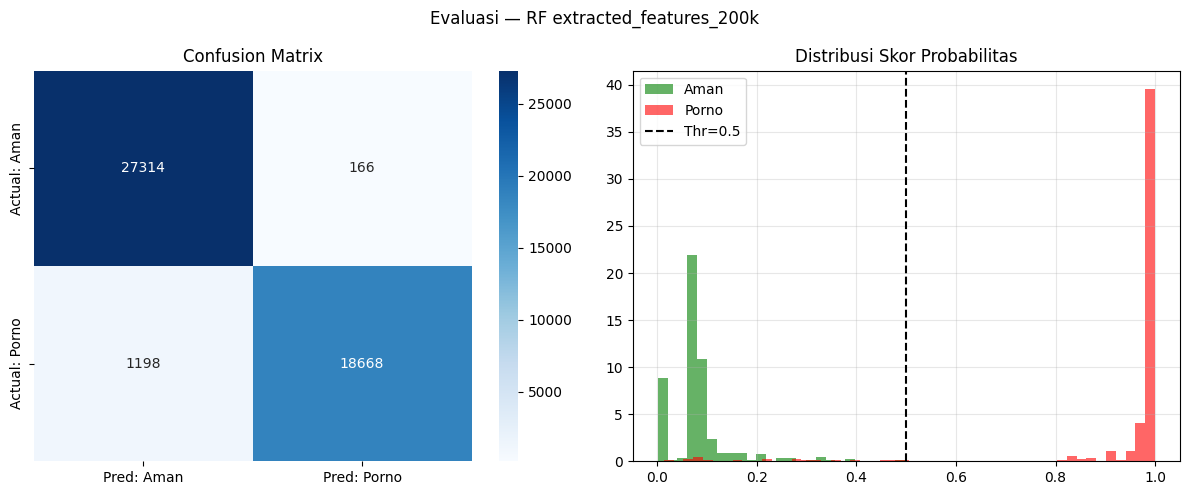

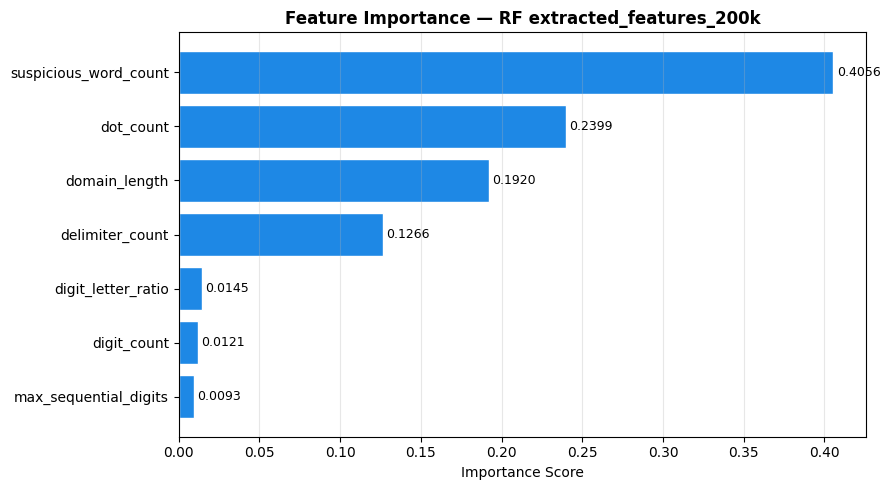

Overfitting: train=0.9656 | test=0.9712 | gap=-0.0056  OK
ONNX out: [0.0385 0.9615] | sklearn: [0.0385 0.9615] | delta: 0.000000 OK
TFLite: 1889.8 KB | 100 pohon | depth=10
TFLite acc=0.9712 | delta=0.0000 OK
  OK url_classifier_rf_extracted_features_200k.tflite
  OK rf_extracted_features_200k.onnx
  OK rf_model_extracted_features_200k.joblib
  OK evaluation_extracted_features_200k.png
  OK feature_importance_extracted_features_200k.png
  OK classification_report_extracted_features_200k.txt

SELESAI extracted_features_200k — acc=0.9712 | f1=0.9648 | auc=0.9877 | 1889.8KB
-----------------------------------------------------------------

  extracted_features_300k  (300,000 baris | unik: 7,361 | aman: 150,000 porno: 150,000)
F5 (int count): OK
F7 (max len)  : OK
Train: 243,083 | Test: 56,917 | overlap grup: 0 (OK)
Balance train: 0.506 | test: 0.474

Training extracted_features_300k...
Selesai: 7.3 detik | 100 pohon | max_depth=10

Test Set — extracted_features_300k (prevalence-weighted, 

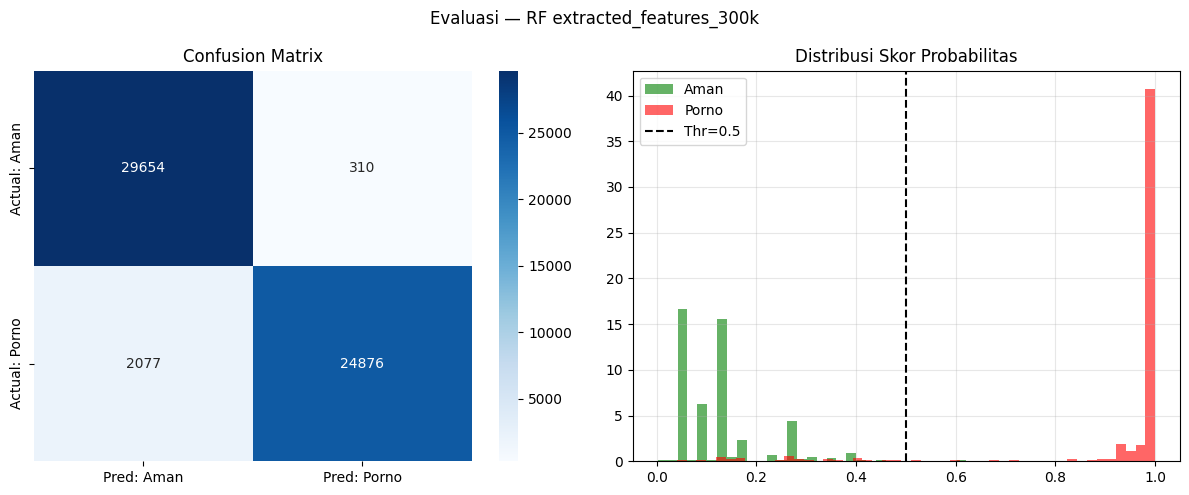

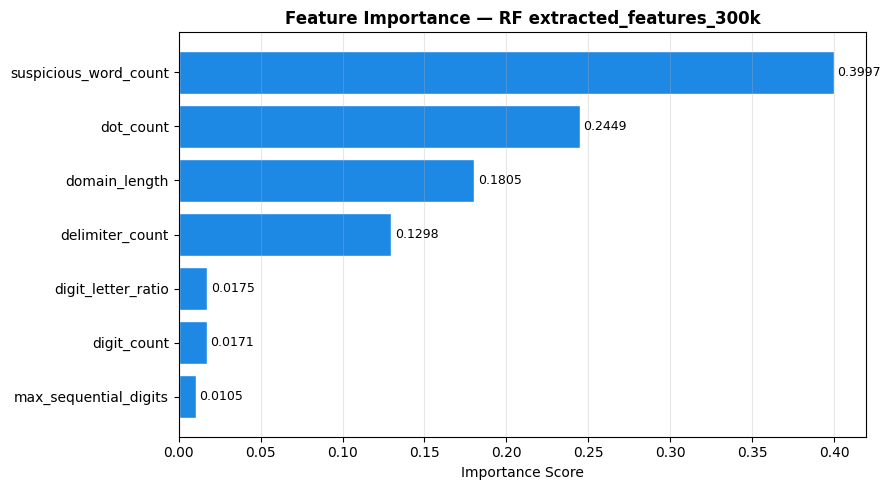

Overfitting: train=0.9622 | test=0.9581 | gap=0.0041  OK
ONNX out: [0.0746 0.9254] | sklearn: [0.0746 0.9254] | delta: 0.000000 OK
TFLite: 2072.6 KB | 100 pohon | depth=10
TFLite acc=0.9581 | delta=0.0000 OK
  OK url_classifier_rf_extracted_features_300k.tflite
  OK rf_extracted_features_300k.onnx
  OK rf_model_extracted_features_300k.joblib
  OK evaluation_extracted_features_300k.png
  OK feature_importance_extracted_features_300k.png
  OK classification_report_extracted_features_300k.txt

SELESAI extracted_features_300k — acc=0.9581 | f1=0.9542 | auc=0.9858 | 2072.6KB
-----------------------------------------------------------------

all_results: /content/drive/MyDrive/Tugas Akhir/Training/Random-Forest/training_baru/rf_all_results.json

SEMUA TRAINING SELESAI — RINGKASAN
Dataset                       Rows    Unik    Train    Test     Acc      F1     AUC      KB
--------------------------------------------------------------------------------------------
extracted_features_100k    100

In [6]:
# Set True hanya jika F5/F7 masih boolean di dataset (akan rekalkulasi dari kolom 'url')
RECOMPUTE_FEATURES = False

import gc
from onnx import helper, TensorProto
from sklearn.model_selection import StratifiedGroupKFold

all_results = {}

for csv_path in DATASET_FILES:
    SIZE_LABEL = os.path.splitext(os.path.basename(csv_path))[0]

    # ── 1. Load CSV ───────────────────────────────────────────────
    df = pd.read_csv(csv_path)
    total_rows_awal = len(df)

    # ── 2. Bersihkan NA saja — SEMUA baris dipakai ────────────────
    # (Tidak ada dedup/undersampling: seluruh dataset digunakan.
    #  Kebebasan dari data leakage dijamin oleh group-aware split di tahap 5,
    #  bukan oleh penghapusan duplikat.)
    df = df.dropna(subset=FEATURE_COLS + [LABEL_COL]).reset_index(drop=True)
    n_unik  = df.drop_duplicates(subset=FEATURE_COLS + [LABEL_COL]).shape[0]
    n_aman  = int((df[LABEL_COL] == 0).sum())
    n_porno = int((df[LABEL_COL] == 1).sum())

    print(f'\n{"="*65}')
    print(f'  {SIZE_LABEL}  ({total_rows_awal:,} baris | unik: {n_unik:,} | '
          f'aman: {n_aman:,} porno: {n_porno:,})')
    print(f'{"="*65}')

    SIZE_SAVE_PATH = SAVE_PATH + f'{SIZE_LABEL}/'
    os.makedirs(SIZE_SAVE_PATH, exist_ok=True)

    df_bal = df  # nama dipertahankan agar konsisten dengan tahap berikutnya
    del df
    gc.collect()

    # ── 3. (Opsional) Hitung ulang fitur dari URL ─────────────────
    if RECOMPUTE_FEATURES:
        if 'url' not in df_bal.columns:
            print('  Kolom url tidak ditemukan, lewati rekalkulasi.')
        else:
            print('  Menghitung ulang fitur dari URL...')
            t0 = time.time()
            feat_list = df_bal['url'].apply(extract_features).tolist()
            feat_df   = pd.DataFrame(feat_list, columns=FEATURE_COLS)
            for col in FEATURE_COLS:
                df_bal[col] = feat_df[col].values
            print(f'  Selesai dalam {time.time()-t0:.1f} detik')

    # ── 4. Validasi F5 & F7 ───────────────────────────────────────
    f5_ok = not (set(df_bal['suspicious_word_count'].unique()) <= {0, 1})
    f7_ok = not (set(df_bal['max_sequential_digits'].unique()) <= {0, 1})
    print(f'F5 (int count): {"OK" if f5_ok else "PERHATIAN: masih boolean, set RECOMPUTE_FEATURES=True"}')
    print(f'F7 (max len)  : {"OK" if f7_ok else "PERHATIAN: masih boolean, set RECOMPUTE_FEATURES=True"}')

    # ── 5. Group-aware split (80/20, tanpa leakage) ──────────────
    # Setiap vektor fitur identik diperlakukan sebagai satu "grup".
    # StratifiedGroupKFold menjamin satu grup tidak pernah berada di
    # train dan test sekaligus -> tidak ada kebocoran, seluruh baris dipakai.
    X = df_bal[FEATURE_COLS].values.astype(np.float32)
    y = df_bal[LABEL_COL].values
    groups = pd.factorize(
        pd.Series(map(tuple, X.tolist()))  # id unik per kombinasi 7 fitur
    )[0]

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(sgkf.split(X, y, groups))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Sanity check anti-leakage
    bocor = len(set(groups[train_idx]) & set(groups[test_idx]))
    print(f'Train: {len(X_train):,} | Test: {len(X_test):,} | '
          f'overlap grup: {bocor} ({"OK" if bocor == 0 else "BOCOR!"})')
    print(f'Balance train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

    # ── 6. Training ───────────────────────────────────────────────
    rf_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    print(f'\nTraining {SIZE_LABEL}...')
    t0 = time.time()
    rf_model.fit(X_train, y_train)
    durasi = time.time() - t0
    print(f'Selesai: {durasi:.1f} detik | {len(rf_model.estimators_)} pohon | max_depth={rf_model.max_depth}')

    # ── 7. Evaluasi Test Set ──────────────────────────────────────
    y_pred      = rf_model.predict(X_test)
    y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    print(f'\nTest Set — {SIZE_LABEL} (prevalence-weighted, seluruh data):')
    print(f'  Accuracy : {acc:.4f}  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}  F1-Score : {f1:.4f}  AUC: {roc_auc:.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['Aman (0)', 'Pornografi (1)'], digits=4))

    # Metrik referensi: akurasi pada vektor unik saja (pattern-level)
    uniq_mask = ~pd.DataFrame(X_test).duplicated().values
    acc_unik  = accuracy_score(y_test[uniq_mask], y_pred[uniq_mask])
    print(f'  (Referensi) Accuracy pada {uniq_mask.sum():,} vektor unik di test: {acc_unik:.4f}')

    # ── 8. Confusion Matrix + Distribusi Skor ────────────────────
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Evaluasi — RF {SIZE_LABEL}', fontsize=12)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Aman', 'Pred: Porno'],
                yticklabels=['Actual: Aman', 'Actual: Porno'], ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[1].hist(y_pred_prob[y_test == 0], bins=50, alpha=0.6,
                 label='Aman', color='green', density=True)
    axes[1].hist(y_pred_prob[y_test == 1], bins=50, alpha=0.6,
                 label='Porno', color='red', density=True)
    axes[1].axvline(0.5, color='black', linestyle='--', label='Thr=0.5')
    axes[1].set_title('Distribusi Skor Probabilitas')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/content/evaluation_{SIZE_LABEL}.png', dpi=120, bbox_inches='tight')
    plt.show(); plt.close()

    # ── 9. Feature Importance ─────────────────────────────────────
    imp_df = pd.DataFrame({
        'Fitur'     : FEATURE_COLS,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(imp_df['Fitur'], imp_df['Importance'], color='#1E88E5', edgecolor='white')
    for bar, val in zip(bars, imp_df['Importance']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(f'Feature Importance — RF {SIZE_LABEL}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/content/feature_importance_{SIZE_LABEL}.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    # ── 10. Cek Overfitting ───────────────────────────────────────
    y_pred_train = rf_model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    gap = acc_train - acc
    print(f'Overfitting: train={acc_train:.4f} | test={acc:.4f} | gap={gap:.4f}', end='  ')
    print('OK' if gap < 0.02 else ('Sedikit overfit' if gap < 0.05 else 'Overfit — kurangi max_depth'))

    # ── 11. Simpan Joblib ─────────────────────────────────────────
    joblib_path = f'/content/rf_model_{SIZE_LABEL}.joblib'
    joblib.dump(rf_model, joblib_path, compress=3)

    # ── 12. sklearn → ONNX (dengan graph surgery p0 = 1 - p1) ────
    options  = {id(rf_model): {'zipmap': False}}
    onnx_mdl = convert_sklearn(
        rf_model,
        initial_types=[('float_input', FloatTensorType([None, len(FEATURE_COLS)]))],
        options=options, target_opset=11
    )
    prob_out = next((o for o in onnx_mdl.graph.output if 'prob' in o.name.lower()),
                    onnx_mdl.graph.output[1] if len(onnx_mdl.graph.output) >= 2
                    else onnx_mdl.graph.output[0])

    # PERBAIKAN: beberapa kombinasi versi skl2onnx menghasilkan kolom p0
    # yang salah (-p1) sementara p1 selalu benar. Graph surgery ini
    # menghitung ulang p0 := 1 - p1 di dalam graf, kebal terhadap bug itu.
    prob_name = prob_out.name
    onnx_mdl.graph.initializer.extend([
        helper.make_tensor('fx_start', TensorProto.INT64, [1], [1]),
        helper.make_tensor('fx_end',   TensorProto.INT64, [1], [2]),
        helper.make_tensor('fx_axes',  TensorProto.INT64, [1], [1]),
        helper.make_tensor('fx_one',   TensorProto.FLOAT, [1], [1.0]),
    ])
    onnx_mdl.graph.node.extend([
        helper.make_node('Slice',  [prob_name, 'fx_start', 'fx_end', 'fx_axes'], ['fx_p1'], name='fx_get_p1'),
        helper.make_node('Sub',    ['fx_one', 'fx_p1'], ['fx_p0'], name='fx_one_minus_p1'),
        helper.make_node('Concat', ['fx_p0', 'fx_p1'], ['probabilities_fixed'], axis=1, name='fx_concat'),
    ])
    del onnx_mdl.graph.output[:]
    onnx_mdl.graph.output.append(
        helper.make_tensor_value_info('probabilities_fixed', TensorProto.FLOAT, [None, 2]))
    onnx.checker.check_model(onnx_mdl)

    onnx_path = f'/content/rf_{SIZE_LABEL}.onnx'
    onnx.save(onnx_mdl, onnx_path)

    sess     = ort.InferenceSession(onnx_path)
    inp_name = sess.get_inputs()[0].name
    out_name = sess.get_outputs()[0].name
    test_vec = np.array([[10, 0, 1, 0, 1, 0.0, 0]], dtype=np.float32)
    onnx_out = sess.run([out_name], {inp_name: test_vec})[0][0]
    sk_prob  = rf_model.predict_proba(test_vec)[0]
    onnx_delta = max(abs(onnx_out - sk_prob))
    print(f'ONNX out: {np.round(onnx_out, 4)} | sklearn: {np.round(sk_prob, 4)} | delta: {onnx_delta:.6f}',
          'OK' if onnx_delta < 0.01 else 'PERHATIAN')

    # ── 13. RF → TFLite (TF Module, depth-scaling) ───────────────
    # onnx2tf tidak mendukung op TreeEnsembleClassifier (ai.onnx.ml),
    # jadi konversi dilakukan langsung dari struktur pohon sklearn.
    n_trees   = len(rf_model.estimators_)
    max_nodes = max(est.tree_.node_count for est in rf_model.estimators_)
    depth_max = max(est.tree_.max_depth  for est in rf_model.estimators_)

    feat_arr  = np.zeros((n_trees, max_nodes), dtype=np.int32)
    thr_arr   = np.zeros((n_trees, max_nodes), dtype=np.float32)
    left_arr  = np.zeros((n_trees, max_nodes), dtype=np.int32)
    right_arr = np.zeros((n_trees, max_nodes), dtype=np.int32)
    val_arr   = np.zeros((n_trees, max_nodes, 2), dtype=np.float32)

    for i_t, est in enumerate(rf_model.estimators_):
        t_ = est.tree_
        n_ = t_.node_count
        feat_arr[i_t, :n_] = np.maximum(t_.feature, 0)
        thr_arr [i_t, :n_] = t_.threshold
        l_ = t_.children_left.copy()
        r_ = t_.children_right.copy()
        is_leaf = l_ == -1
        idx_ = np.arange(n_)
        l_[is_leaf] = idx_[is_leaf]
        r_[is_leaf] = idx_[is_leaf]
        left_arr [i_t, :n_] = l_
        right_arr[i_t, :n_] = r_
        v_ = t_.value[:, 0, :].astype(np.float64)
        v_ = v_ / np.clip(v_.sum(axis=1, keepdims=True), 1e-12, None)
        val_arr[i_t, :n_, :] = v_.astype(np.float32)

    class RFLite(tf.Module):
        def __init__(self):
            super().__init__()
            self.feat  = tf.constant(feat_arr)
            self.thr   = tf.constant(thr_arr)
            self.left  = tf.constant(left_arr)
            self.right = tf.constant(right_arr)
            self.val   = tf.constant(val_arr)
            self.tidx  = tf.constant(np.arange(n_trees, dtype=np.int32))

        @tf.function
        def predict(self, float_input):
            x = tf.reshape(float_input, [-1])
            node = tf.zeros([n_trees], dtype=tf.int32)
            for _ in range(depth_max):
                gi   = tf.stack([self.tidx, node], axis=1)
                f_g  = tf.gather_nd(self.feat, gi)
                th_g = tf.gather_nd(self.thr,  gi)
                xv   = tf.gather(x, f_g)
                l_g  = tf.gather_nd(self.left,  gi)
                r_g  = tf.gather_nd(self.right, gi)
                node = tf.where(xv <= th_g, l_g, r_g)
            gi = tf.stack([self.tidx, node], axis=1)
            probs = tf.reduce_mean(tf.gather_nd(self.val, gi), axis=0)
            return tf.reshape(probs, [1, 2])

    rf_lite  = RFLite()
    concrete = rf_lite.predict.get_concrete_function(
        tf.TensorSpec([1, len(FEATURE_COLS)], tf.float32, name='float_input'))
    converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete], rf_lite)
    tflite_model = converter.convert()
    tflite_path  = f'/content/url_classifier_rf_{SIZE_LABEL}.tflite'
    with open(tflite_path, 'wb') as f_out:
        f_out.write(tflite_model)
    print(f'TFLite: {len(tflite_model)/1024:.1f} KB | {n_trees} pohon | depth={depth_max}')
    del feat_arr, thr_arr, left_arr, right_arr, val_arr
    gc.collect()

    # ── 14. Verifikasi TFLite pada Test Set ──────────────────────
    interp = tf.lite.Interpreter(model_content=tflite_model)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    assert inp_det['dtype'] == np.float32, 'Input harus float32'
    assert out_det['shape'][-1] == 2,      'Output harus [1,2]'

    tflite_probs = []
    BATCH_VER = 512
    for start in range(0, len(X_test), BATCH_VER):
        batch = X_test[start:start+BATCH_VER].astype(np.float32)
        for j in range(len(batch)):
            interp.set_tensor(inp_det['index'], batch[j:j+1])
            interp.invoke()
            tflite_probs.append(float(interp.get_tensor(out_det['index'])[0][1]))

    tflite_binary = (np.array(tflite_probs) >= 0.5).astype(int)
    tflite_acc    = accuracy_score(y_test, tflite_binary)
    tflite_f1     = f1_score(y_test, tflite_binary, zero_division=0)
    tflite_prec   = precision_score(y_test, tflite_binary, zero_division=0)
    tflite_rec    = recall_score(y_test, tflite_binary, zero_division=0)
    delta_acc     = abs(acc - tflite_acc)
    print(f'TFLite acc={tflite_acc:.4f} | delta={delta_acc:.4f}', 'OK' if delta_acc < 0.005 else 'PERHATIAN')

    # ── 15. Simpan ke Drive ───────────────────────────────────────
    report_str  = classification_report(y_test, y_pred,
                      target_names=['Aman (0)', 'Pornografi (1)'], digits=4)
    report_path = f'/content/classification_report_{SIZE_LABEL}.txt'
    with open(report_path, 'w') as f_out:
        f_out.write(f'Classification Report — RF {SIZE_LABEL}\n{"="*50}\n\n')
        f_out.write(report_str)
        f_out.write(f'\nAccuracy : {acc:.4f}\nPrecision: {prec:.4f}\n'
                    f'Recall   : {rec:.4f}\nF1-Score : {f1:.4f}\nAUC-ROC  : {roc_auc:.4f}\n')

    # Pastikan folder tujuan ada — Drive kadang terputus saat proses panjang.
    # Salinan dengan 3x percobaan + jeda agar mount sempat tersambung lagi.
    def _salin_aman(src, dst, n_coba=3):
        for i in range(n_coba):
            try:
                os.makedirs(os.path.dirname(dst), exist_ok=True)
                shutil.copy(src, dst)
                return True
            except (FileNotFoundError, OSError):
                time.sleep(3)  # beri waktu Drive reconnect
        return False

    for src, fname in [
        (tflite_path,                                      f'url_classifier_rf_{SIZE_LABEL}.tflite'),
        (onnx_path,                                        f'rf_{SIZE_LABEL}.onnx'),
        (joblib_path,                                      f'rf_model_{SIZE_LABEL}.joblib'),
        (f'/content/evaluation_{SIZE_LABEL}.png',         f'evaluation_{SIZE_LABEL}.png'),
        (f'/content/feature_importance_{SIZE_LABEL}.png', f'feature_importance_{SIZE_LABEL}.png'),
        (report_path,                                      f'classification_report_{SIZE_LABEL}.txt'),
    ]:
        if os.path.exists(src):
            ok = _salin_aman(src, SIZE_SAVE_PATH + fname)
            print(f'  {"OK" if ok else "GAGAL (cek koneksi Drive)"} {fname}')

    # ── 16. Catat hasil ───────────────────────────────────────────
    all_results[SIZE_LABEL] = {
        'csv_file'         : os.path.basename(csv_path),
        'total_rows_csv'   : total_rows_awal,
        'unique_rows'      : int(n_unik),
        'n_aman'           : n_aman,
        'n_porno'          : n_porno,
        'total_samples'    : len(df_bal),
        'train_samples'    : len(X_train),
        'test_samples'     : len(X_test),
        'train_time_sec'   : round(durasi, 1),
        'n_estimators'     : rf_model.n_estimators,
        'max_depth'        : str(rf_model.max_depth),
        'accuracy'         : round(acc,         4),
        'accuracy_unik'    : round(acc_unik,    4),
        'precision'        : round(prec,        4),
        'recall'           : round(rec,         4),
        'f1_score'         : round(f1,          4),
        'auc_roc'          : round(roc_auc,     4),
        'train_accuracy'   : round(acc_train,   4),
        'overfit_gap'      : round(gap,         4),
        'onnx_delta'       : round(float(onnx_delta), 6),
        'tflite_accuracy'  : round(tflite_acc,  4),
        'tflite_f1'        : round(tflite_f1,   4),
        'tflite_prec'      : round(tflite_prec, 4),
        'tflite_rec'       : round(tflite_rec,  4),
        'tflite_delta_acc' : round(delta_acc,   4),
        'tflite_kb'        : round(len(tflite_model) / 1024, 1),
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'feature_importance': {col: round(float(imp), 4)
                               for col, imp in zip(FEATURE_COLS, rf_model.feature_importances_)},
    }
    print(f'\nSELESAI {SIZE_LABEL} — acc={acc:.4f} | f1={f1:.4f} | auc={roc_auc:.4f} | {len(tflite_model)/1024:.1f}KB')
    print('-' * 65)

    # Bersihkan memori sebelum dataset berikutnya
    del df_bal, X, y, groups, X_train, X_test, y_train, y_test, tflite_probs, rf_lite, concrete
    gc.collect()

# ── Simpan semua hasil ke JSON ────────────────────────────────────
results_path = SAVE_PATH + 'rf_all_results.json'
with open(results_path, 'w') as f_out:
    json.dump(all_results, f_out, indent=2)
print(f'\nall_results: {results_path}')

# ── Ringkasan Perbandingan ────────────────────────────────────────
print(f'\n{"="*92}')
print('SEMUA TRAINING SELESAI — RINGKASAN')
print(f'{"="*92}')
header = f'{"Dataset":<25} {"Rows":>8} {"Unik":>7} {"Train":>8} {"Test":>7} {"Acc":>7} {"F1":>7} {"AUC":>7} {"KB":>7}'
print(header)
print('-' * 92)
for lbl, r in all_results.items():
    baris = f'{lbl:<25} {r["total_rows_csv"]:>8,} {r["unique_rows"]:>7,} '
    baris += f'{r["train_samples"]:>8,} {r["test_samples"]:>7,} '
    baris += f'{r["accuracy"]:>7.4f} {r["f1_score"]:>7.4f} {r["auc_roc"]:>7.4f} {r["tflite_kb"]:>7.1f}'
    print(baris)
print('=' * 92)